# GSB 5544 — Data Wrangling: Tidy Data and the Big Five Verbs — SOLUTION  
**SOLUTION**

Every section starts with a **question** about the crime data; the pandas verb is just how we answer it.

**Data:** `sc_crime_sample.csv` — a random sample of **50,000 offense records** reported by South Carolina police agencies to the FBI's National Incident-Based Reporting System (NIBRS), 1991–2020. (The full classroom file has 11 million rows; the sample keeps every pattern and loads in seconds.) One **row** = one offense record.

| Column | Meaning | Type |
|---|---|---|
| `ori` | ID of the reporting police agency | identifier |
| `year`, `month`, `incident_date` | when it happened | categorical (ordered) / date |
| `incident_number` | incident ID (unique only within an agency and year) | identifier |
| `ucr_offense_code`, `crime_cat`, `crime` | FBI code, broad category, specific offense | categorical |
| `completed` | `True` = completed, `False` = attempted | categorical |
| `location_type` | where (residence/home, highway/road/alley, …) | categorical |
| `weapon_force_1` | weapon involved — only recorded for some offense types, otherwise missing | categorical |
| `bias_motivation` | hate-crime bias, if any | categorical |
| `arrest_made` | `True` if anyone was arrested for the incident | categorical |

> *Sex offenses and aggravated assaults were removed from the classroom file, so violent-crime totals here are understated. Reported crime ≠ all crime.*

Textbook: [Chapter 4 — Tabular Data and Basic Data Operations](https://ds-ml-with-python.github.io/Course-Textbook/03-basic_data_operations.html)


In [1]:
import pandas as pd
crime = pd.read_csv("https://raw.githubusercontent.com/gato365/gsb5544_instructor_learn_prep/main/assignments/Data/sc_crime_sample.csv")
crime.head()


,ori,year,incident_number,incident_date,month,ucr_offense_code,crime_cat,crime,completed,location_type,weapon_force_1,bias_motivation,arrest_made
0,SC0060000,1991,CG190KW2LC2A,1991-01-01,1,26A,Fraud Offenses,False Pretenses/Swindle/Confidence Game,True,residence/home,NaN,NaN,False
1,SC0070000,1991,76-4YLY8F39G,1991-01-01,1,23G,Larceny/Theft Offenses,Theft of Motor Vehicle Parts or Accessories,True,commercial/office building,NaN,NaN,False
2,SC0080000,1991,9A-HQ0708XXA,1991-01-01,1,26A,Fraud Offenses,False Pretenses/Swindle/Confidence Game,True,residence/home,NaN,NaN,False
3,SC0080100,1991,I04XBZU72 N,1991-01-01,1,13B,Assault Offenses,Simple Assault,True,residence/home,"personal weapons (hands, feet, teeth, etc.)",NaN,False
4,SC0100100,1991,7N2N18B-F39G,1991-01-01,1,13B,Assault Offenses,Simple Assault,True,parking lot/garage,"personal weapons (hands, feet, teeth, etc.)",NaN,False


In [2]:
crime.shape


(50000, 13)

---
## 1. *Is this data "tidy"?*

Before wrangling anything, we need a standard for what a **good** table looks like. The book's definition:

> A dataset is **tidy** if
> 1. every **column** is a **variable**,
> 2. every **row** is an **observation**, and
> 3. every **cell** is a **single value**.

Why care? Because `plotnine`, `.groupby`, and nearly every tool we'll use assume it. `aes(x = "crime_cat")` only works if `crime_cat` is a *column* holding *one value per row*.

**Q: Is `crime` tidy?** Look at `crime.head()` above.

- each column (`year`, `crime_cat`, `location_type`, …) is one variable ✔
- each row is one offense record ✔
- each cell holds one value ✔

**Yes.** Now here is the *same information*, arranged the way a report or spreadsheet often arrives:


In [3]:
wide = pd.read_csv("https://raw.githubusercontent.com/gato365/gsb5544_instructor_learn_prep/main/assignments/Data/sc_crime_by_year_wide.csv")
wide.head()


,crime_cat,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Animal Cruelty Offenses,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,207,304,321,313
1,Arson,1190,1284,500,817,834,1042,1139,981,1104,...,995,863,781,702,714,688,674,644,594,710
2,Assault Offenses,44915,49349,53481,62033,57908,72013,77915,79902,80506,...,72841,71653,67751,66827,66444,64416,61365,62589,60964,56627
3,Bribery,12,4,1,4,3,3,5,4,0,...,15,5,6,7,12,10,9,6,7,4
4,Burglary/Breaking & Entering,43161,50377,48565,47948,38746,48038,47469,45731,40991,...,47094,45181,40747,36782,34261,32826,30133,28902,25968,21659


**Q: Is `wide` tidy?** Count the variables: there are really three — *crime category*, *year*, and *number of offenses*. But `year` is smeared across 30 column **headers**, and the "number of offenses" variable is spread across 30 columns. Rule 1 is broken (column headers are *values*, not variable names), so rule 2 is too (one row holds 30 observations).

**Q: What would I need to do to plot offenses per year for one category?** With `wide` I'd have to hand-pick 30 columns. The fix is to **melt** the wide columns into two long ones — a `year` column and a `n_offenses` column:


In [4]:
tidy = wide.melt(id_vars = "crime_cat",        # the column(s) to keep as-is
                 var_name = "year",           # the old column HEADERS become this variable
                 value_name = "n_offenses")   # the old cell VALUES become this variable
tidy["year"] = tidy["year"].astype(int)       # headers were text; make year a number
tidy.head()


,crime_cat,year,n_offenses
0,Animal Cruelty Offenses,1991,0
1,Arson,1991,1190
2,Assault Offenses,1991,44915
3,Bribery,1991,12
4,Burglary/Breaking & Entering,1991,43161


In [5]:
tidy.shape        # 22 categories x 30 years = 660 observations, one per row


(660, 3)

Now every tool works. (`.melt()` and its opposite, `.pivot()`, get their own chapter next week; today just recognize *untidy* when you see it.)


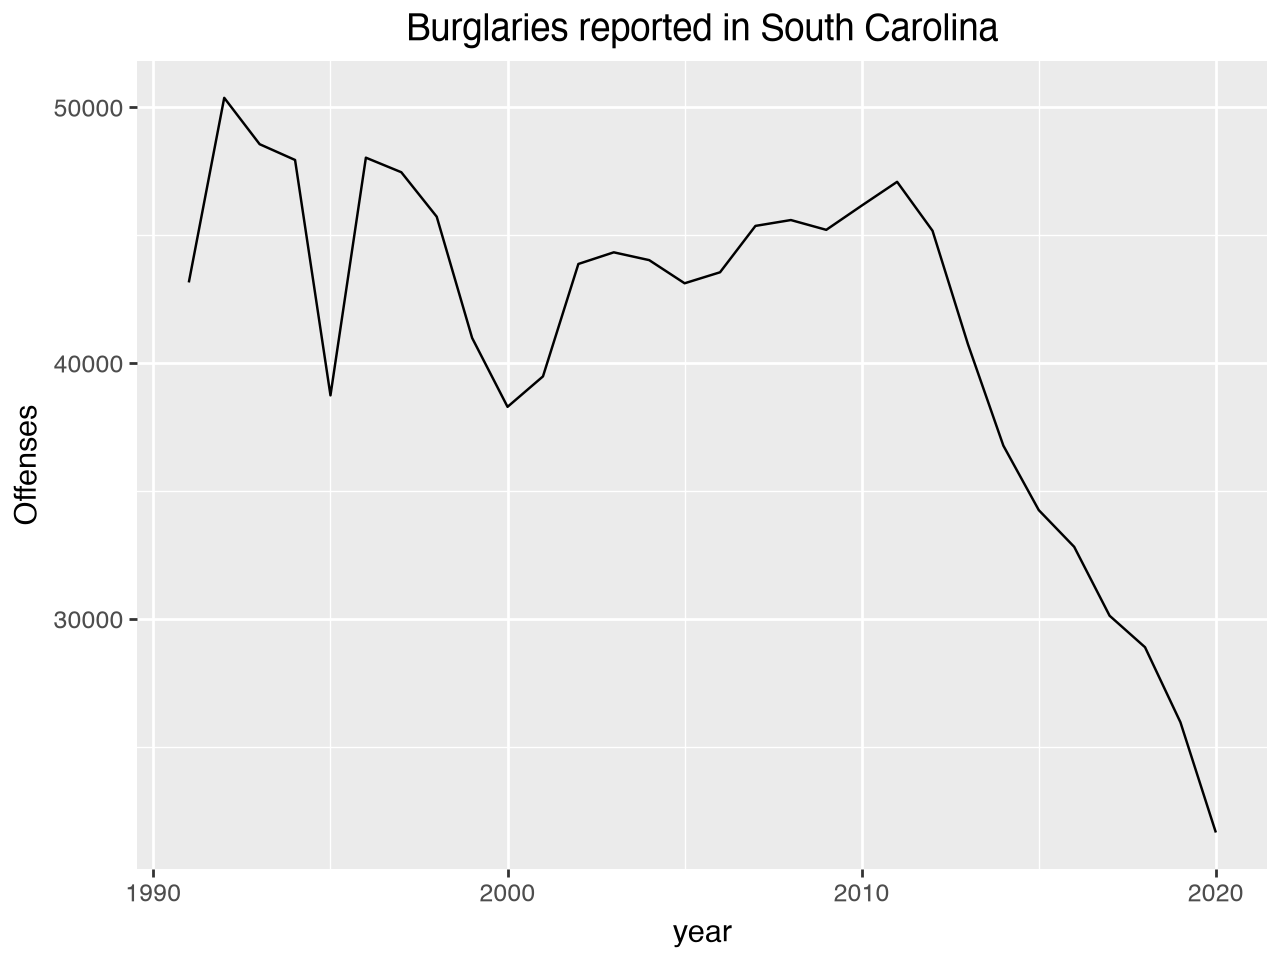

In [6]:
from plotnine import *

(ggplot(tidy[tidy["crime_cat"] == "Burglary/Breaking & Entering"], aes(x = "year", y = "n_offenses"))
 + geom_line()
 + labs(title = "Burglaries reported in South Carolina", y = "Offenses")
)


✅ **Check:** below is a tiny table a police chief might send you. Which rule(s) of tidy data does it break, and what would the tidy version's columns be? (Write your answer in the cell — no code needed.)

| agency | 2019_arrests | 2020_arrests |
|---|---|---|
| Columbia | 4,120 | 3,880 |
| Charleston | 2,910 | 2,650 |


**Answer:** the column headers `2019_arrests` / `2020_arrests` are *values* of a year variable (rule 1), so each row holds two observations (rule 2). Tidy columns: `agency`, `year`, `arrests` — four rows.


---
## 2. The Big Five verbs

Almost everything you'll do to a table is one of five operations. If you've seen R's `dplyr`, these are its verbs; pandas spells them differently but they are the same ideas.

| Verb | Question it answers | `dplyr` | pandas |
|---|---|---|---|
| **select** | *Which columns do I need?* | `select()` | `df[["a", "b"]]`, `df.loc[:, ...]` |
| **filter** | *Which rows do I need?* | `filter()` | `df[condition]` |
| **arrange** | *In what order?* | `arrange()` | `df.sort_values()` |
| **mutate** | *What new column do I need?* | `mutate()` | `df["new"] = ...` |
| **summarize** | *What is the one-number (or one-row-per-group) answer?* | `summarize()` | `.mean()`, `.describe()`, `.value_counts()`, `.groupby()` |

We'll meet each one because a question forces us to.


---
## 3. *What is even in this data?*  → `.unique()`, `.nunique()`, `.value_counts()`, `.describe()`

Before asking sharp questions we need the lay of the land. **Q: What kinds of crime are recorded?**


In [7]:
crime["crime_cat"].unique()          # the distinct levels


<StringArray>
[                          'Fraud Offenses',
                   'Larceny/Theft Offenses',
                         'Assault Offenses',
                   'Drug/Narcotic Offenses',
             'Burglary/Breaking & Entering',
 'Destruction/Damage/Vandalism of Property',
                   'Counterfeiting/Forgery',
                                  'Robbery',
                      'Motor Vehicle Theft',
                        'Homicide Offenses',
                                    'Arson',
                 'Stolen Property Offenses',
                    'Weapon Law Violations',
                     'Kidnapping/Abduction',
                        'Gambling Offenses',
                             'Embezzlement',
                    'Prostitution Offenses',
             'Pornography/Obscene Material',
                      'Extortion/Blackmail',
                  'Animal Cruelty Offenses']
Length: 20, dtype: str

In [8]:
crime["crime_cat"].nunique()         # how many distinct levels


20

20 categories in our sample (the full file has 22 — two are so rare they didn't land in 50,000 rows). **Q: Which are common and which are rare?** `.value_counts()` counts rows per level, sorted from most to least:


In [9]:
crime["crime_cat"].value_counts()


crime_cat
Larceny/Theft Offenses                      16902
Assault Offenses                             9519
Destruction/Damage/Vandalism of Property     6248
Burglary/Breaking & Entering                 5687
Drug/Narcotic Offenses                       4580
Motor Vehicle Theft                          1978
Fraud Offenses                               1976
Counterfeiting/Forgery                        946
Robbery                                       723
Weapon Law Violations                         587
Stolen Property Offenses                      325
Embezzlement                                  127
Arson                                         118
Kidnapping/Abduction                          114
Prostitution Offenses                          64
Homicide Offenses                              42
Gambling Offenses                              31
Pornography/Obscene Material                   21
Animal Cruelty Offenses                         7
Extortion/Blackmail                     

In [10]:
# Q: As a SHARE of all offenses?   normalize=True -> proportions
crime["crime_cat"].value_counts(normalize = True).round(3)


crime_cat
Larceny/Theft Offenses                      0.338
Assault Offenses                            0.190
Destruction/Damage/Vandalism of Property    0.125
Burglary/Breaking & Entering                0.114
Drug/Narcotic Offenses                      0.092
Motor Vehicle Theft                         0.040
Fraud Offenses                              0.040
Counterfeiting/Forgery                      0.019
Robbery                                     0.014
Weapon Law Violations                       0.012
Stolen Property Offenses                    0.006
Embezzlement                                0.003
Arson                                       0.002
Kidnapping/Abduction                        0.002
Prostitution Offenses                       0.001
Homicide Offenses                           0.001
Gambling Offenses                           0.001
Pornography/Obscene Material                0.000
Animal Cruelty Offenses                     0.000
Extortion/Blackmail                     

Larceny/theft alone is about a third of all offense records; assault and vandalism are next. Homicide is a few tenths of a percent — rare events need a big sample.

**Q: What does `.describe()` tell me?** It depends on the *type* of the column:


In [11]:
crime["year"].describe()            # quantitative -> count, mean, sd, min, quartiles, max


count    50000.000000
mean      2006.039920
std          8.308316
min       1991.000000
25%       1999.000000
50%       2006.000000
75%       2013.000000
max       2020.000000
Name: year, dtype: float64

In [12]:
crime["location_type"].describe()   # categorical -> count, #unique, most common level, its frequency


count              50000
unique                43
top       residence/home
freq               22439
Name: location_type, dtype: object

(Is the "mean year" 2006 meaningful? Not really — `year` is an *ordered categorical* here, as with the coffee data last week. `.describe()` computes whatever the dtype allows; **you** decide whether it means anything.)

✅ **Check:** how many distinct `location_type` levels are there, and what share of offenses happen at a `residence/home`?


In [13]:
print(crime["location_type"].nunique())
crime["location_type"].value_counts(normalize = True).head()


43


location_type
residence/home                0.44878
highway/road/alley            0.10544
other/unknown                 0.08548
commercial/office building    0.05332
parking lot/garage            0.05306
Name: proportion, dtype: float64

**Answer:** 43 location types; about 45% of offense records are at a residence/home — by far the most common place, ahead of roads and parking lots.


---
## 4. *Which columns do I need?*  → **select**

**Q: For a "what, when, where" report, which columns matter?** Only a few — the IDs and codes are noise for this question. Selecting columns keeps the screen readable and makes later steps faster.


In [14]:
report = crime[["incident_date", "crime_cat", "crime", "location_type", "arrest_made"]]
report.head()


,incident_date,crime_cat,crime,location_type,arrest_made
0,1991-01-01,Fraud Offenses,False Pretenses/Swindle/Confidence Game,residence/home,False
1,1991-01-01,Larceny/Theft Offenses,Theft of Motor Vehicle Parts or Accessories,commercial/office building,False
2,1991-01-01,Fraud Offenses,False Pretenses/Swindle/Confidence Game,residence/home,False
3,1991-01-01,Assault Offenses,Simple Assault,residence/home,False
4,1991-01-01,Assault Offenses,Simple Assault,parking lot/garage,False


(Same `[[ ]]` from last week; `crime.loc[:, ["incident_date", "crime_cat"]]` is equivalent. A *list* of names → DataFrame; a single name → Series.)


---
## 5. *Which rows do I need?*  → **filter**

**Q: How many shoplifting offenses were recorded in 2019?**

A condition on a column gives `True`/`False` per row; putting it inside `[ ]` keeps the `True` rows. Two conditions combine with `&` (and) / `|` (or), each in parentheses.


In [15]:
shop_2019 = crime[(crime["crime"] == "Shoplifting") & (crime["year"] == 2019)]
shop_2019.shape


(117, 13)

In [16]:
# Q: Which offenses involved ANY kind of firearm?   .isin() = "is one of these"
guns = ["handgun", "rifle", "shotgun", "firearm (type not stated)", "other firearm"]
crime[crime["weapon_force_1"].isin(guns)]["crime"].value_counts().head()


crime
Weapon Law Violations                  453
Robbery                                342
Kidnapping/Abduction                    31
Murder & Non-negligent Manslaughter     26
Negligent Manslaughter                   2
Name: count, dtype: int64

In [17]:
# Q: How many offense records have NO weapon information at all?   .isna() -> True where missing
crime["weapon_force_1"].isna().sum()


np.int64(41167)

Most rows have no weapon recorded — NIBRS only collects weapons for certain offense types (assault, robbery, homicide, …). **Missing here means "not applicable", not "unknown".** Always check `.isna()` before you compute with a column.

*Fill in the blanks.*

✅ **Check:** how many offenses in the sample were **attempted but not completed** (`completed == False`) **and** ended in an arrest?


In [18]:
crime[(crime["completed"] == False) & (crime["arrest_made"] == True)].shape[0]


266

---
## 6. *In what order?*  → **arrange**

**Q: What are the most recent offenses in the sample?**

`.sort_values()` sorts by one or more columns. `ascending = False` reverses.


In [19]:
crime.sort_values("incident_date", ascending = False).head()


,ori,year,incident_number,incident_date,month,ucr_offense_code,crime_cat,crime,completed,location_type,weapon_force_1,bias_motivation,arrest_made
49999,SC0460400,2020,VX2IJGYEPU72,2020-12-31,12,520,Weapon Law Violations,Weapon Law Violations,True,residence/home,handgun,no bias motivation,True
49998,SC0460300,2020,Q91MR-S39D5I,2020-12-31,12,09A,Homicide Offenses,Murder & Non-negligent Manslaughter,True,residence/home,unknown,no bias motivation,False
49997,SC0160000,2020,Z82JWI8BLVI9,2020-12-31,12,520,Weapon Law Violations,Weapon Law Violations,True,commercial/office building,rifle,no bias motivation,True
49996,SC005SP00,2020,4ODQLYMU-HQP,2020-12-31,12,35A,Drug/Narcotic Offenses,Drug/Narcotic Violations,True,highway/road/alley,NaN,no bias motivation,True
49993,SC0370000,2020,O80JQ0728GJA,2020-12-30,12,23H,Larceny/Theft Offenses,All Other Larceny,True,residence/home,NaN,no bias motivation,False


In [20]:
# Q: Within each year, which categories come first alphabetically?   a list sorts by several columns, in order
crime.sort_values(["year", "crime_cat"]).head()


,ori,year,incident_number,incident_date,month,ucr_offense_code,crime_cat,crime,completed,location_type,weapon_force_1,bias_motivation,arrest_made
60,SC0230000,1991,6N0BSA3972 N,1991-01-11,1,200,Arson,Arson,False,residence/home,NaN,NaN,False
62,SC0400100,1991,N5-ZUO24G0W5,1991-01-11,1,200,Arson,Arson,True,residence/home,NaN,NaN,False
1024,SC0230000,1991,-T143J05VSCT,1991-09-24,9,200,Arson,Arson,True,highway/road/alley,NaN,NaN,False
1069,SC0150000,1991,6N-VSY3 728N,1991-10-10,10,200,Arson,Arson,False,residence/home,NaN,NaN,False
1091,SC0230000,1991,P3147DNOQ-F3,1991-10-21,10,200,Arson,Arson,True,highway/road/alley,NaN,NaN,False


**Nothing changed.** Sorting (and selecting, and filtering) *returns a new table*; `crime` itself is untouched:


In [21]:
crime.head(2)          # still the original order


,ori,year,incident_number,incident_date,month,ucr_offense_code,crime_cat,crime,completed,location_type,weapon_force_1,bias_motivation,arrest_made
0,SC0060000,1991,CG190KW2LC2A,1991-01-01,1,26A,Fraud Offenses,False Pretenses/Swindle/Confidence Game,True,residence/home,NaN,NaN,False
1,SC0070000,1991,76-4YLY8F39G,1991-01-01,1,23G,Larceny/Theft Offenses,Theft of Motor Vehicle Parts or Accessories,True,commercial/office building,NaN,NaN,False


To keep a result, **assign it**: `crime = crime.sort_values(...)`. The book warns against `inplace=True` — an overwrite is a big decision and should be visible on the left of an `=`.

✅ **Check:** among `Homicide Offenses`, which agency (`ori`) has the most records? (Hint: filter, then `.value_counts()`; or filter then sort.)


In [22]:
crime[crime["crime_cat"] == "Homicide Offenses"]["ori"].value_counts().head(3)


ori
SC0400100    4
SC0270000    3
SC0380000    2
Name: count, dtype: int64

---
## 7. *What new column do I need?*  → **mutate**

New columns are made by assigning to a name that doesn't exist yet: `crime["new"] = <expression>`. The four moves from the book:

**Q: Is an offense violent, property, or something else?** The 22 categories are too fine. **Recode** with `.map()` (last week's tool) — anything not listed becomes missing, then `.fillna()` catches the rest:


In [23]:
violent  = ["Assault Offenses", "Homicide Offenses", "Robbery", "Kidnapping/Abduction", "Human Trafficking"]
property = ["Larceny/Theft Offenses", "Burglary/Breaking & Entering", "Motor Vehicle Theft", "Arson",
            "Destruction/Damage/Vandalism of Property", "Stolen Property Offenses"]

crime["crime_group"] = (crime["crime_cat"]
                        .map({**{c: "violent" for c in violent}, **{c: "property" for c in property}})
                        .fillna("other")
                        .astype("category"))
crime["crime_group"].value_counts()


crime_group
property    31258
violent     10398
other        8344
Name: count, dtype: int64

**Q: Which decade?** `year` is quantitative-looking, so arithmetic works: integer-divide by 10 and multiply back.


In [24]:
crime["decade"] = (crime["year"] // 10 * 10).astype(str) + "s"
crime["decade"].value_counts().sort_index()


decade
1990s    12982
2000s    18112
2010s    17400
2020s     1506
Name: count, dtype: int64

**Q: Was a firearm involved?** A **boolean** column from a condition. `1 * (...)` turns `True/False` into `1/0` — handy for later modeling.


In [25]:
crime["firearm"] = 1 * crime["weapon_force_1"].isin(guns)
crime["firearm"].value_counts()


firearm
0    49145
1      855
Name: count, dtype: int64

**Q: What day of the week?** `incident_date` is text. Convert it to a real date (`pd.to_datetime`, as with the coffee data), then pull out the weekday.


In [26]:
crime["incident_date"] = pd.to_datetime(crime["incident_date"])
crime["weekday"] = crime["incident_date"].dt.day_name()
crime["weekday"].value_counts()


weekday
Friday       8070
Saturday     7556
Wednesday    7100
Thursday     7067
Monday       7041
Tuesday      6916
Sunday       6250
Name: count, dtype: int64

`.value_counts()` sorts by count, so the weekdays are out of order. Same fix as last week — declare an **ordered** categorical:


In [27]:
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
crime["weekday"] = pd.Categorical(crime["weekday"], categories = days, ordered = True)
crime["weekday"].value_counts().sort_index()


weekday
Monday       7041
Tuesday      6916
Wednesday    7100
Thursday     7067
Friday       8070
Saturday     7556
Sunday       6250
Name: count, dtype: int64

✅ **Check:** make a column `season` from `month` (`Dec–Feb` = "winter", `Mar–May` = "spring", `Jun–Aug` = "summer", `Sep–Nov` = "fall") and show the counts. Use `.map()` or `pd.cut()` — which is more natural here, and why?


In [28]:
season_map = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring", 5: "spring",
              6: "summer", 7: "summer", 8: "summer", 9: "fall", 10: "fall", 11: "fall"}
crime["season"] = crime["month"].map(season_map).astype("category")
crime["season"].value_counts()


season
summer    13396
spring    12758
fall      12106
winter    11740
Name: count, dtype: int64

**Answer:** `.map()` — `pd.cut()` bins a *range* of numbers, but December (12) and January (1) belong to the same season, which no single set of cut points can express. Summer is the busiest season.


---
## 8. *What is the one-number answer?*  → **summarize**

**Q: What share of offenses end in an arrest?**

`arrest_made` is `True`/`False`. Python treats `True` as 1, so the **mean of a boolean is a proportion**.


In [29]:
crime["arrest_made"].mean()


np.float64(0.23994)

About one in four. But that single number hides the interesting part.

**Q: Which kinds of crime are most likely to end in an arrest?** Split the rows into groups, then summarize *each group*: `.groupby("group")["column"].statistic()`.


In [30]:
crime.groupby("crime_cat")["arrest_made"].mean().sort_values(ascending = False).round(3)


crime_cat
Prostitution Offenses                       0.859
Drug/Narcotic Offenses                      0.815
Weapon Law Violations                       0.700
Stolen Property Offenses                    0.658
Homicide Offenses                           0.619
Gambling Offenses                           0.548
Embezzlement                                0.472
Kidnapping/Abduction                        0.465
Animal Cruelty Offenses                     0.429
Assault Offenses                            0.291
Counterfeiting/Forgery                      0.251
Pornography/Obscene Material                0.238
Robbery                                     0.220
Fraud Offenses                              0.209
Arson                                       0.178
Larceny/Theft Offenses                      0.144
Burglary/Breaking & Entering                0.102
Destruction/Damage/Vandalism of Property    0.098
Motor Vehicle Theft                         0.097
Extortion/Blackmail                     

Prostitution, drug, and weapon offenses are usually "cleared" — the offense *is* the arrest. Larceny, burglary, and vandalism are rarely solved. **Reported arrest rate says as much about how a crime is discovered as about policing.**


In [31]:
# Q: Several summaries at once?   .agg() with a dictionary: column -> statistic(s)
crime.groupby("crime_group").agg(n = ("crime_cat", "size"),
                                 arrest_rate = ("arrest_made", "mean"),
                                 firearm_rate = ("firearm", "mean")).round(3)


,n,arrest_rate,firearm_rate
crime_group,,,
other,8344,0.591,0.054
property,31258,0.130,0.000
violent,10398,0.289,0.039


✅ **Check:** has the arrest rate changed over time? Compute it by `decade`, then by `year`, and plot the yearly series with `geom_line`.


decade
1990s    0.205
2000s    0.229
2010s    0.273
2020s    0.288
Name: arrest_made, dtype: float64


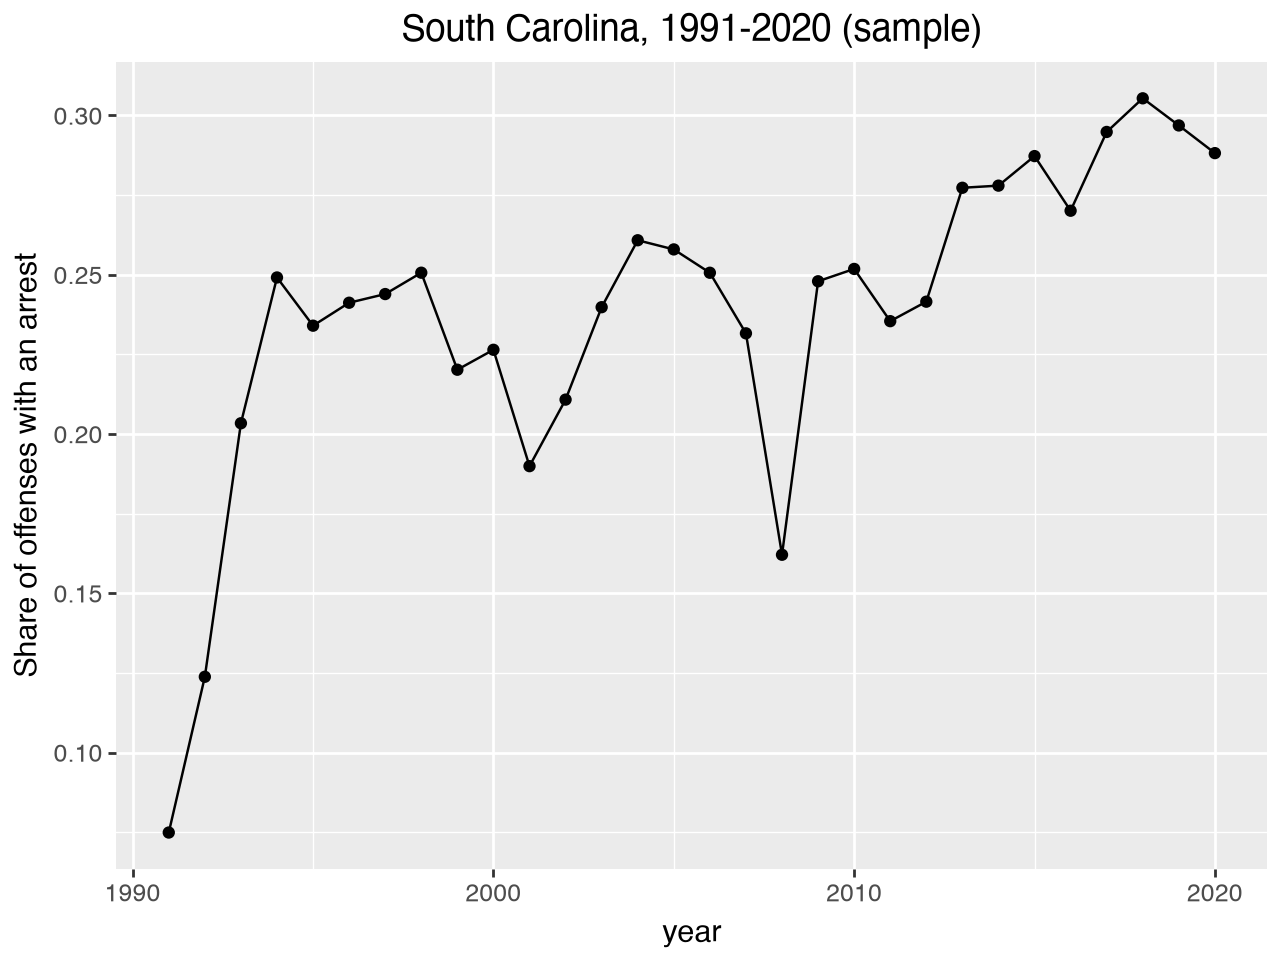

In [32]:
print(crime.groupby("decade")["arrest_made"].mean().round(3))

by_year = crime.groupby("year")["arrest_made"].mean().reset_index()
(ggplot(by_year, aes(x = "year", y = "arrest_made"))
 + geom_line()
 + geom_point()
 + labs(y = "Share of offenses with an arrest", title = "South Carolina, 1991-2020 (sample)")
)


**Answer:** the arrest share *rises*, from about 21% in the 1990s to about 27% in the 2010s. Before concluding "policing got better", remember Section 8: drug and weapon offenses are arrests almost by definition, and PA 5 below shows they became a bigger share of what gets recorded.


---
## 9. *Do two categorical variables go together?*  → `pd.crosstab()`

**Q: Are attempted offenses less likely to end in an arrest than completed ones?**

`.value_counts()` describes one categorical variable. For **two**, we need a **cross-tabulation** (a "crosstab" or contingency table): rows = levels of one, columns = levels of the other, cells = counts.


In [33]:
pd.crosstab(crime["completed"], crime["arrest_made"])


arrest_made,False,True
completed,,
False,1030,266
True,36973,11731


Counts alone don't answer the question — there are far more completed offenses. We need **conditional proportions**: *within each row*, what share had an arrest? `normalize = "index"` divides each row by its total.

| `normalize=` | Each cell is … |
|---|---|
| `False` (default) | a count |
| `True` | a share of the **grand total** |
| `"index"` | a share of its **row** |
| `"columns"` | a share of its **column** |


In [34]:
pd.crosstab(crime["completed"], crime["arrest_made"], normalize = "index").round(3)


arrest_made,False,True
completed,,
False,0.795,0.205
True,0.759,0.241


About 24% of completed offenses lead to an arrest vs. about 21% of attempted ones — a modest gap, in the direction we guessed.


In [35]:
# Q: Where do violent vs. property vs. other offenses happen?   margins=True adds row/column totals
pd.crosstab(crime["crime_group"], crime["location_type"], margins = True).iloc[:, :6]   # first 6 locations


location_type,ATM separate from bank,abandoned/condemned structure,air/bus/train terminal,amusement park,arena/stadium/fairgrounds/coliseum,auto dealership new/used
crime_group,,,,,,
other,4,2,6,4,2,7
property,2,12,31,8,1,48
violent,0,0,17,0,1,2
All,6,14,54,12,4,57


✅ **Check:** does the weekday pattern differ by `crime_group`? Build the crosstab of `crime_group` (rows) by `weekday` (columns) as **row proportions**. Which group is most concentrated on weekends?


In [36]:
pd.crosstab(crime["crime_group"], crime["weekday"], normalize = "index").round(3)


weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
crime_group,,,,,,,
other,0.134,0.149,0.150,0.162,0.171,0.133,0.101
property,0.144,0.138,0.143,0.139,0.162,0.150,0.123
violent,0.137,0.130,0.133,0.131,0.151,0.168,0.150


**Answer:** violent offenses tilt toward Saturday/Sunday (~16% each vs ~13% midweek); property offenses are flat across the week, with a slight Friday bump.


---
## 10. Practice Activities — you pick the verb

For each question, first say **which verb(s)** (select / filter / arrange / mutate / summarize / crosstab) you need, then write the code. Solutions will be posted after class.

**PA 1.** What are the five most common *specific* offenses (`crime`) among **property** crimes?


In [37]:
# filter -> summarize
crime[crime["crime_group"] == "property"]["crime"].value_counts().head(5)


crime
All Other Larceny                           7683
Destruction/Damage/Vandalism of Property    6248
Burglary/Breaking & Entering                5687
Theft From Motor Vehicle                    3614
Shoplifting                                 2923
Name: count, dtype: int64

**PA 2.** Where does shoplifting happen? Show the top 5 `location_type` values for `Shoplifting` as *proportions*.


In [38]:
# filter -> summarize (normalize)
crime[crime["crime"] == "Shoplifting"]["location_type"].value_counts(normalize = True).head(5).round(3)


location_type
department/discount store          0.447
grocery/supermarket                0.176
convenience store                  0.173
specialty store (tv, fur, etc.)    0.067
commercial/office building         0.038
Name: proportion, dtype: float64

**PA 3.** Create a boolean column `hate_crime` that is `True` when `bias_motivation` is recorded and is **not** `"no bias motivation"` or `"unknown bias motivation"`. How many hate-crime records are in the sample, and which `crime_cat` do they fall into most often?


In [39]:
# mutate -> summarize
not_bias = ["no bias motivation", "unknown bias motivation"]
crime["hate_crime"] = crime["bias_motivation"].notna() & ~crime["bias_motivation"].isin(not_bias)
print(crime["hate_crime"].sum())
crime[crime["hate_crime"]]["crime_cat"].value_counts().head(3)


6


crime_cat
Destruction/Damage/Vandalism of Property    3
Drug/Narcotic Offenses                      1
Weapon Law Violations                       1
Name: count, dtype: int64

**PA 4.** Is the firearm rate different for violent offenses at a `residence/home` versus on a `highway/road/alley`? (filter → groupby → mean)


In [40]:
# filter -> summarize by group
v = crime[(crime["crime_group"] == "violent") & (crime["location_type"].isin(["residence/home", "highway/road/alley"]))]
v.groupby("location_type")["firearm"].mean().round(3)


location_type
highway/road/alley    0.092
residence/home        0.015
Name: firearm, dtype: float64

**PA 5.** Build a crosstab of `decade` by `crime_group` as **row proportions**. Has the *mix* of reported crime shifted across decades? Then draw it: `geom_bar(position = "fill")` with `x = "decade"` and `fill = "crime_group"`.


crime_group  other  property  violent
decade                               
1990s        0.105     0.673    0.223
2000s        0.161     0.627    0.212
2010s        0.213     0.594    0.193
2020s        0.250     0.547    0.203


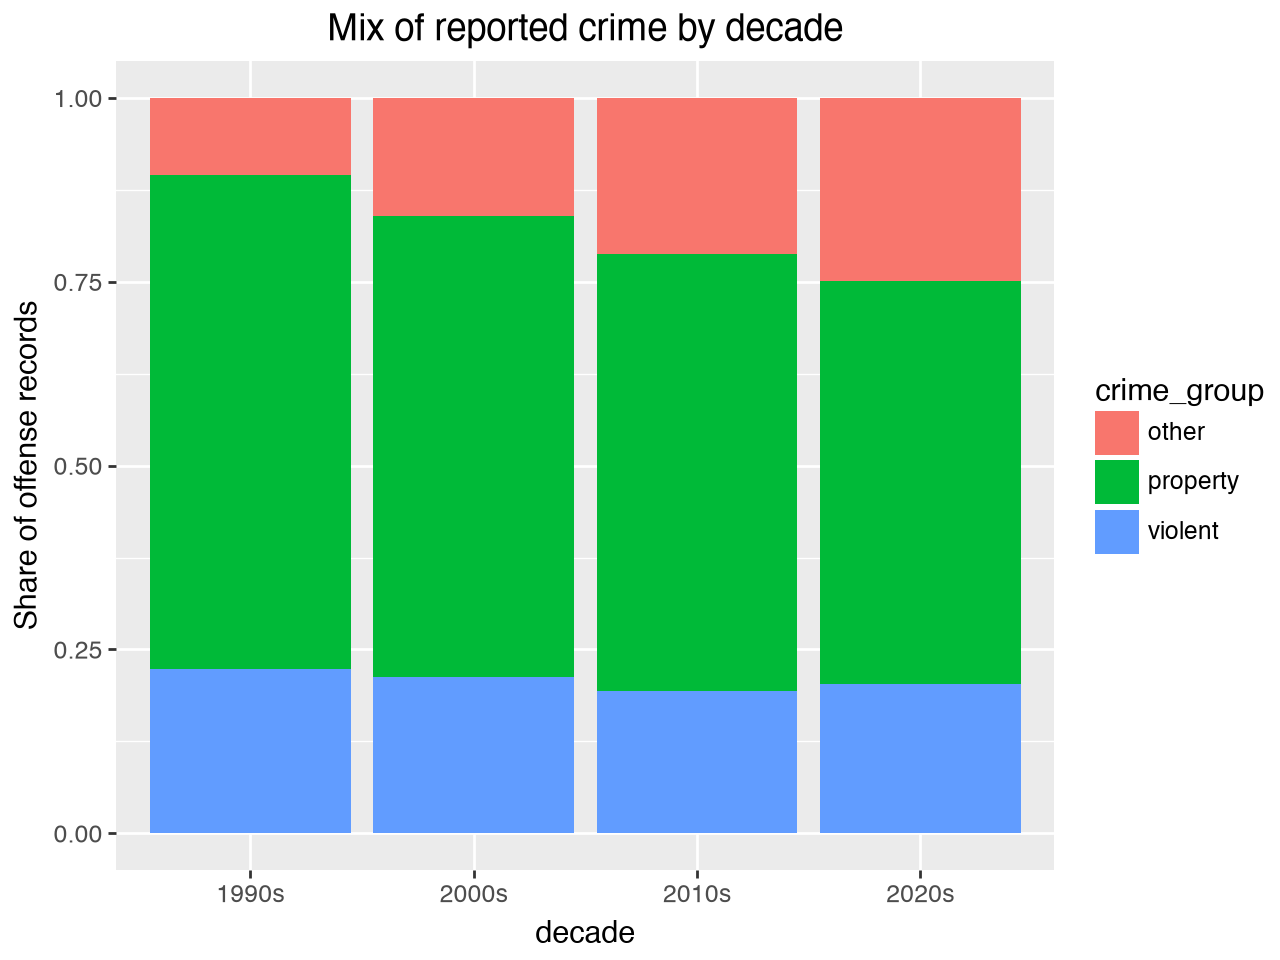

In [41]:
print(pd.crosstab(crime["decade"], crime["crime_group"], normalize = "index").round(3))

(ggplot(crime, aes(x = "decade", fill = "crime_group"))
 + geom_bar(position = "fill")
 + labs(y = "Share of offense records", title = "Mix of reported crime by decade")
)


**Answer:** property crime's share falls across the decades while "other" (mostly drug offenses) rises — a change in what police *record* as much as in what happens.

**PA 6.** The table below is not tidy. Type it into a DataFrame with `pd.DataFrame({...})`, melt it into tidy form, and then answer: which agency had the larger *increase* in offenses from 2018 to 2020?

| agency | offenses_2018 | offenses_2019 | offenses_2020 |
|---|---|---|---|
| Greenville | 5100 | 5300 | 4900 |
| Myrtle Beach | 3900 | 4300 | 4600 |


In [42]:
agencies = pd.DataFrame({"agency": ["Greenville", "Myrtle Beach"],
                         "offenses_2018": [5100, 3900],
                         "offenses_2019": [5300, 4300],
                         "offenses_2020": [4900, 4600]})

long = agencies.melt(id_vars = "agency", var_name = "year", value_name = "offenses")
long["year"] = long["year"].str.replace("offenses_", "").astype(int)

change = long[long["year"] == 2020].set_index("agency")["offenses"] - long[long["year"] == 2018].set_index("agency")["offenses"]
change.sort_values(ascending = False)


agency
Myrtle Beach    700
Greenville     -200
Name: offenses, dtype: int64

**Answer:** Myrtle Beach rose by 700; Greenville fell by 200.

**PA 7 (write, don't code).** Section 8 showed the arrest share rising from the 1990s to the 2010s. A news story says "South Carolina police got 30% better at solving crimes." Using what you saw in Sections 8–9 and PA 5, give two reasons the *data* might show that rise even if policing did not change.


**Answer:** (1) the *mix* changed — drug and weapon offenses (arrest rates of 70–80%, because the offense is discovered *by* the arrest) grew from ~10% to ~25% of records, which raises the overall rate even if every category's own rate stayed flat; (2) this is *reported and recorded* crime — which agencies report, and what they record, changed over 30 years. A fair comparison holds the crime mix fixed (compare rates *within* a category).


---
## Summary

| Question | Verb | Tool |
|---|---|---|
| Is this table tidy? | — | every column a variable, every row an observation, every cell one value; `.melt()` to fix wide data |
| What's in this column? | summarize | `.unique()`, `.nunique()`, `.value_counts(normalize=)`, `.describe()` |
| Which columns? | **select** | `df[["a", "b"]]`, `df.loc[:, [...]]` |
| Which rows? | **filter** | `df[cond]`, `&`, `|`, `.isin()`, `.isna()` |
| In what order? | **arrange** | `.sort_values(cols, ascending=)` — assign to keep |
| What new column? | **mutate** | `df["new"] = ...`, `.map()`, arithmetic, `1 * (cond)`, `pd.to_datetime`, `.dt.day_name()` |
| One-number answer, overall or per group? | **summarize** | `.mean()` (of a boolean = proportion), `.groupby("g")["x"].mean()`, `.agg()` |
| Do two categoricals go together? | crosstab | `pd.crosstab(a, b, normalize="index", margins=True)` |
